# Detecting expr3.interval plot (0614 TA-only)

Run this notebook on af309 with the `xfold-scripts` kernel. Set `RUN_ROOTS` to one or more host data directories; all roots are plotted in one figure.


In [ ]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

DATE_BASE = "20260615"
WALK_TAG = "walk20"
SHUFFLE_ID = "shuffle0"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]


def latest_run_root(host, shuffle_id=SHUFFLE_ID):
    base = Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/{host}/outputDetecting/expr3interval/{WALK_TAG}")
    stamps = sorted([p for p in base.iterdir() if p.is_dir()]) if base.exists() else []
    for stamp in reversed(stamps):
        root = stamp / f"detecting.expr3.interval.{shuffle_id}"
        if root.exists():
            return root
    return base / "REPLACE_TIMESTAMP" / f"detecting.expr3.interval.{shuffle_id}"

RUN_ROOTS_SHUFFLE0 = [latest_run_root(host, "shuffle0") for host in HOST_ORDER]
RUN_ROOTS_SHUFFLE1 = [latest_run_root(host, "shuffle1") for host in HOST_ORDER]
RUN_ROOTS_SHUFFLE2 = [latest_run_root(host, "shuffle2") for host in HOST_ORDER]
RUN_ROOTS = RUN_ROOTS_SHUFFLE0

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "scripts":
    REPO_ROOT = REPO_ROOT.parent
OUT_DIR = REPO_ROOT / "scripts_plot/outputDetecting"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RL_QUANTILE_BOUNDARY = [0.0, 0.9]
RH_QUANTILE_BOUNDARY = [0.9, 0.995]
Y_LIMIT_MAX = 100

TIMER_COLORS = {
    "tsc": "tab:blue",
    "tsc_asym": "tab:cyan",
    "clock_gettime": "tab:orange",
    "mpi_wtime": "tab:green",
    "papi": "tab:red",
    "papix6": "tab:purple",
    "likwid": "tab:brown",
    "cntvct": "tab:cyan",
    "cntvct_fence": "tab:olive",
    "cntvcto": "tab:pink",
}

RUN_TAG = f"multi_host_{RUN_ROOTS[0].name}" if len(RUN_ROOTS) > 1 else RUN_ROOTS[0].name

for root in RUN_ROOTS:
    print(root)
print("host_order:", HOST_ORDER)


/astrum/home/hpchzy/code/data/20260614/camd9554n1/outputDetecting/expr2fsize/walk20/20260614-222832/detecting.expr3.interval.shuffle1


In [ ]:
def parse_meta(path):
    d = {}
    if not path.exists():
        return d
    for line in path.read_text(errors="ignore").splitlines():
        if "=" in line:
            k, v = line.split("=", 1)
            d[k.strip()] = v.strip()
    return d


def read_values(path):
    vals = []
    for line in path.read_text(errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        try:
            vals.append(float(line.split(",")[-1]))
        except ValueError:
            pass
    return vals


def ta_from_run_dir(run_dir, meta):
    m = re.search(r"_ta([0-9.]+)", run_dir.name)
    if m:
        return float(m.group(1))
    return float(meta.get("mu_ns", meta.get("interval_ns", 0)) or 0)


def wasserstein_distance(u_values, v_values):
    u = np.sort(np.asarray(u_values, dtype=float))
    v = np.sort(np.asarray(v_values, dtype=float))
    if u.size == 0 or v.size == 0:
        return float("nan")
    all_values = np.concatenate((u, v))
    all_values.sort()
    deltas = np.diff(all_values)
    if deltas.size == 0:
        return 0.0
    u_cdf = np.searchsorted(u, all_values[:-1], side="right") / u.size
    v_cdf = np.searchsorted(v, all_values[:-1], side="right") / v.size
    return float(np.sum(np.abs(u_cdf - v_cdf) * deltas))


def quantile_window(values, lo, hi):
    lb = np.quantile(values, lo)
    ub = np.quantile(values, hi)
    return values[(values >= lb) & (values <= ub)], lb, ub


def spread_wasserstein(values):
    return wasserstein_distance(values, np.zeros_like(values))


def rl_rh_detail(measured, theory):
    measured_raw = np.asarray(measured, dtype=float)
    theory_raw = np.asarray(theory, dtype=float)
    measured_aligned = measured_raw - np.min(measured_raw)
    theory_aligned = theory_raw - np.min(theory_raw)
    measured_rl, _, _ = quantile_window(measured_aligned, *RL_QUANTILE_BOUNDARY)
    theory_rl, _, _ = quantile_window(theory_aligned, *RL_QUANTILE_BOUNDARY)
    measured_rh, _, _ = quantile_window(measured_aligned, *RH_QUANTILE_BOUNDARY)
    theory_rh, _, _ = quantile_window(theory_aligned, *RH_QUANTILE_BOUNDARY)
    low_num = spread_wasserstein(measured_rl)
    low_den = spread_wasserstein(theory_rl)
    high_num = spread_wasserstein(measured_rh)
    high_den = spread_wasserstein(theory_rh)
    rl = low_num / low_den if low_den else math.nan
    rh = high_num / high_den if high_den else math.nan
    return rl, rh, low_num, low_den, high_num, high_den


In [ ]:
rows = []
for run_root in RUN_ROOTS:
    for cdf in sorted(run_root.rglob("*_ta_cdf.csv")):
        run_dir = cdf.parent
        combo_dir = run_dir.parent
        meta = parse_meta(run_dir / "meta.txt") or parse_meta(combo_dir / "meta.txt")
        measured = read_values(cdf)
        if not measured:
            continue
        ta = ta_from_run_dir(run_dir, meta)
        rows.append({
            "host": meta.get("host", run_root.parts[-5] if len(run_root.parts) >= 5 else ""),
            "expr": meta.get("expr_name", run_root.name),
            "np": int(meta.get("np", 0) or 0),
            "timer": meta.get("timer", cdf.parents[2].name),
            "interval_ns": int(float(meta.get("interval_ns", meta.get("mu_ns", 0)) or 0)),
            "fkern": meta.get("fkern", ""),
            "rkern": meta.get("rkern", ""),
            "ta": ta,
            "n_measured": len(measured),
            "measured": measured,
            "theory": [ta] * len(measured),
            "run_dir": str(run_dir),
            "run_root": str(run_root),
        })

raw = pd.DataFrame(rows)
print(f"roots: {len(RUN_ROOTS)}, cdf files: {len(raw)}")
raw.head()


roots: 1, cdf files: 1320


,host,expr,np,timer,interval_ns,interval_ns,fkern,rkern,ta,n_measured,measured,theory,run_dir,run_root
0,camd9554n1,detecting.expr3.interval,64,clock_gettime,1000,0,copy,none,1000.0,100,"[1021.0, 1021.0, 1021.0, 1021.0, 1021.0, 1021....","[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....",/astrum/home/hpchzy/code/data/20260614/camd955...,/astrum/home/hpchzy/code/data/20260614/camd955...
1,camd9554n1,detecting.expr3.interval,64,clock_gettime,1000,0,copy,none,998.0,100,"[1021.0, 1021.0, 1021.0, 1021.0, 1021.0, 1021....","[998.0, 998.0, 998.0, 998.0, 998.0, 998.0, 998...",/astrum/home/hpchzy/code/data/20260614/camd955...,/astrum/home/hpchzy/code/data/20260614/camd955...
2,camd9554n1,detecting.expr3.interval,64,clock_gettime,1000,0,copy,none,1001.0,100,"[1021.0, 1021.0, 1021.0, 1021.0, 1021.0, 1022....","[1001.0, 1001.0, 1001.0, 1001.0, 1001.0, 1001....",/astrum/home/hpchzy/code/data/20260614/camd955...,/astrum/home/hpchzy/code/data/20260614/camd955...
3,camd9554n1,detecting.expr3.interval,64,clock_gettime,1000,0,copy,none,1001.0,100,"[1021.0, 1021.0, 1021.0, 1021.0, 1021.0, 1021....","[1001.0, 1001.0, 1001.0, 1001.0, 1001.0, 1001....",/astrum/home/hpchzy/code/data/20260614/camd955...,/astrum/home/hpchzy/code/data/20260614/camd955...
4,camd9554n1,detecting.expr3.interval,64,clock_gettime,1000,0,copy,none,997.0,100,"[1021.0, 1021.0, 1021.0, 1021.0, 1021.0, 1021....","[997.0, 997.0, 997.0, 997.0, 997.0, 997.0, 997...",/astrum/home/hpchzy/code/data/20260614/camd955...,/astrum/home/hpchzy/code/data/20260614/camd955...


In [ ]:
summary_rows = []
keys = ["host", "expr", "np", "timer", "interval_ns", "fkern", "rkern"]
for key, g in raw.groupby(keys, dropna=False):
    measured_raw = np.array([x for vals in g["measured"] for x in vals], dtype=float)
    theory_raw = np.array([x for vals in g["theory"] for x in vals], dtype=float)
    rl, rh, ln, ld, hn, hd = rl_rh_detail(measured_raw, theory_raw)
    row = dict(zip(keys, key))
    row.update({
        "rl": rl, "rh": rh,
        "rl_numerator": ln, "rl_denominator": ld,
        "rh_numerator": hn, "rh_denominator": hd,
        "measured_q50": np.quantile(measured_raw - np.min(measured_raw), 0.50),
        "theory_q50": np.quantile(theory_raw - np.min(theory_raw), 0.50),
    })
    summary_rows.append(row)

df = pd.DataFrame(summary_rows)
host_rank = {host: idx for idx, host in enumerate(HOST_ORDER)}
df["host_order"] = df["host"].map(host_rank).fillna(len(host_rank)).astype(int)
df = df.sort_values(["host_order", "np", "timer", "interval_ns"]).reset_index(drop=True)
df = df[(df["timer"] != "cntvct_fence") & (df["timer"] != "tsc_asym")]
mapping = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}
df["hostname"] = df["host"].map(mapping).fillna(df["host"])
df.head()


,host,expr,np,timer,interval_ns,fkern,rkern,rl,rl_numerator,rl_denominator,...,theory_q50,measured_rl_lb_q,measured_rl_ub_q,theory_rl_lb_q,theory_rl_ub_q,measured_rh_lb_q,measured_rh_ub_q,theory_rh_lb_q,theory_rh_ub_q,hostname
1,camd9554n1,detecting.expr3.interval,64,clock_gettime,16,copy,none,3.170965,9.012215,2.842105,...,3.0,0.0,31.0,0.0,4.0,31.0,121.150,4.0,5.0,AMD EPYC 9554
2,camd9554n1,detecting.expr3.interval,64,clock_gettime,32,copy,none,3.354943,9.535102,2.842105,...,3.0,0.0,40.0,0.0,4.0,40.0,171.050,4.0,5.0,AMD EPYC 9554
3,camd9554n1,detecting.expr3.interval,64,clock_gettime,64,copy,none,3.407725,9.685113,2.842105,...,3.0,0.0,40.0,0.0,4.0,40.0,141.000,4.0,5.0,AMD EPYC 9554
4,camd9554n1,detecting.expr3.interval,64,clock_gettime,128,copy,none,3.403119,9.672022,2.842105,...,3.0,0.0,40.0,0.0,4.0,40.0,150.005,4.0,5.0,AMD EPYC 9554
5,camd9554n1,detecting.expr3.interval,64,clock_gettime,256,copy,none,3.520274,10.004989,2.842105,...,3.0,0.0,40.0,0.0,4.0,40.0,221.000,4.0,5.0,AMD EPYC 9554


saved: /astrum/home/hpchzy/code/TacVar/scripts_plot/outputDetecting/detecting_expr3.interval_0614_detecting.expr3.interval.shuffle1.png


/tmp/ipykernel_1501128/526404150.py:40: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


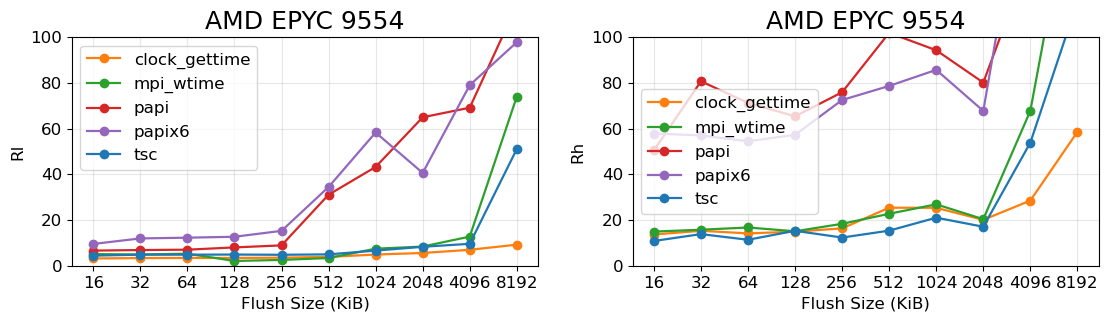

In [ ]:
plot_df = df.copy()
metrics = [("rl", "Rl"), ("rh", "Rh")]
hosts = [host for host in HOST_ORDER if host in set(plot_df["host"].dropna())]
nrows = max(1, len(hosts))
fig, axes = plt.subplots(nrows, 2, figsize=(13.5, 3.2 * nrows), squeeze=False, constrained_layout=True)

interval_ticks = sorted(int(x) for x in plot_df["interval_ns"].dropna().unique())
for row_idx, host in enumerate(hosts):
    host_df = plot_df[plot_df["host"] == host]
    for col_idx, (metric, ylabel) in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        for timer, g in host_df.groupby("timer"):
            g = g.sort_values("interval_ns")
            color = TIMER_COLORS.get(timer, None)
            ax.plot(g["interval_ns"], g[metric], marker="o", linewidth=1.6, label=timer, color=color)

        ax.set_xscale("log", base=10)
        ax.xaxis.set_major_locator(FixedLocator(interval_ticks))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if int(x) in interval_ticks else ""))
        ax.set_xlabel("Interval (ns)", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(0, Y_LIMIT_MAX)
        ax.set_title(f"{mapping.get(host, host)}", fontsize=18)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12)
        ax.tick_params(axis="both", labelsize=12)

FIG_PATH = OUT_DIR / f"detecting_expr3_interval_0614_{RUN_TAG}.png"
fig.savefig(FIG_PATH, dpi=220, bbox_inches="tight")
print(f"saved: {FIG_PATH}")
fig.tight_layout()
plt.show()
